# Modele: Classification du facteur de Risque des Seismes

Ce notebook compare 3 modèles de Machine Learning et enregistre les paramètres,
 métriques et datasets sur le serveur MLflow cible (`http://194.238.26.226:5000`).

**Algorithmes evalues :**
1. Naive Bayes
2. Arbre de decision (Decision Tree)
3. Forêt aleatoire (Random Forest)



In [35]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from sklearn.naive_bayes import GaussianNB
import shap

# --- Intégration MLflow ---
import mlflow
import mlflow.sklearn
from mlflow.data.pandas_dataset import PandasDataset

In [36]:
# Configuration du serveur de suivi MLflow
MLFLOW_TRACKING_URI = "http://194.238.26.226:5000"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment("Risk_Factors_Model_4")

trusted_types = [
    "sklearn.metrics._dist_metrics.EuclideanDistance64",
    "sklearn.neighbors._kd_tree.KDTree",
    "sklearn.tree._tree.Tree"
]

In [37]:
# Configuration de l'affichage
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")


## 1. Chargement des données

In [38]:
file_path = os.path.join("data", "usgs_earthquakes_2025.csv")
df = pd.read_csv(file_path)

print(f"Dimension du dataset : {df.shape}")
df.head()

Dimension du dataset : (29062, 35)


,mag,place,time,updated,tz,url,detail,felt,cdi,mmi,alert,status,tsunami,sig,net,code,ids,sources,types,nst,dmin,rms,gap,magType,type,title,longitude,latitude,depth,event_id,date_time,year,month,day,hour
0,4.2,"70 km W of Abra Pampa, Argentina",1751241591065,1757018402040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,NaN,reviewed,0,271,us,7000q9mu,",us7000q9mu,",",us,",",origin,phase-data,",19.0,1.696,0.70,89.0,mb,earthquake,"M 4.2 - 70 km W of Abra Pampa, Argentina",-66.3753,-22.6251,247.528,us7000q9mu,2025-06-29 23:59:51.065000+00:00,2025,6,29,23
1,2.5,"1 km E of Nikolski, Alaska",1751241495097,1757018405040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,NaN,reviewed,0,96,us,7000qb5r,",ak0258a2rwky,us7000qb5r,",",ak,us,",",origin,phase-data,",17.0,0.035,0.42,198.0,ml,earthquake,"M 2.5 - 1 km E of Nikolski, Alaska",-168.8412,52.9376,61.149,us7000qb5r,2025-06-29 23:58:15.097000+00:00,2025,6,29,23
2,2.8,"31 km SSE of Nikolski, Alaska",1751241219318,1757018405040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,NaN,reviewed,0,121,us,7000qb5v,",ak0258a2qvpj,us7000qb5v,",",ak,us,",",origin,phase-data,",10.0,0.316,0.51,231.0,ml,earthquake,"M 2.8 - 31 km SSE of Nikolski, Alaska",-168.6544,52.6804,35.000,us7000qb5v,2025-06-29 23:53:39.318000+00:00,2025,6,29,23
3,3.8,"153 km S of Nikolski, Alaska",1751241150341,1757018402040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,NaN,reviewed,0,222,us,7000q9mt,",ak0258a2qnbw,us7000q9mt,",",ak,us,",",origin,phase-data,",55.0,1.411,0.42,185.0,mb,earthquake,"M 3.8 - 153 km S of Nikolski, Alaska",-168.5438,51.5761,10.000,us7000q9mt,2025-06-29 23:52:30.341000+00:00,2025,6,29,23
4,4.5,"185 km WSW of Tual, Indonesia",1751240317514,1757018402040,NaN,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,NaN,NaN,NaN,reviewed,0,312,us,7000q9mq,",us7000q9mq,",",us,",",origin,phase-data,",31.0,3.637,0.48,93.0,mb,earthquake,"M 4.5 - 185 km WSW of Tual, Indonesia",131.2977,-6.4544,35.000,us7000q9mq,2025-06-29 23:38:37.514000+00:00,2025,6,29,23


## 2. Définition de la variable cible Y

In [39]:
def define_risk_category(row):
    # Priority 1: Risque Tsunami
    if row.get('tsunami') == 1:
        return 'Risque Tsunami'
    
    # Priority 2: Forte Secousse
    mag = row.get('mag', 0)
    mmi = row.get('mmi', 0)
    if (pd.notna(mag) and mag >= 6.5) or (pd.notna(mmi) and mmi >= 7.0):
        return 'Forte Secousse'
    
    # Priority 3: Forte Exposition
    alert = row.get('alert')
    felt = row.get('felt', 0)
    sig = row.get('sig', 0)
    if (alert in ['orange', 'red']) or (pd.notna(felt) and felt > 1000) or (pd.notna(sig) and sig > 600):
        return 'Forte Exposition'
    
    # Priority 4: Faible Profondeur
    depth = row.get('depth')
    if pd.notna(depth) and pd.notna(mag) and (depth <= 15) and (mag >= 4.0):
        return 'Faible Profondeur'
    
    # Priority 5: Défaut
    return 'Risque Modéré ou Faible'

# Application de la règle métier
df['target_risk_category'] = df.apply(define_risk_category, axis=1)


## 3. Préparation des données & Normalisation

In [40]:
feature_cols_num = ['mag', 'depth', 'sig', 'felt', 'cdi', 'mmi', 'nst', 'dmin', 'rms', 'gap', 'latitude', 'longitude']
feature_cols_cat = ['alert', 'magType']

X = df[feature_cols_num + feature_cols_cat].copy()
y = df['target_risk_category']

# Imputation des valeurs manquantes
X['felt'] = X['felt'].fillna(0)
X['cdi'] = X['cdi'].fillna(0)
X['mmi'] = X['mmi'].fillna(0)

for col in ['nst', 'dmin', 'gap']:
    X[col] = X[col].fillna(X[col].median())

X['alert'] = X['alert'].fillna('none')
X['magType'] = X['magType'].fillna('unknown')

# Encodage catégorique
X = pd.get_dummies(X, columns=feature_cols_cat, drop_first=False)

# Conversion propre de TOUTES les colonnes en float64 (résout l'avertissement MLflow)
X = X.astype(float)

# Split Stratifié 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalisation des variables numériques
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[feature_cols_num] = scaler.fit_transform(X_train[feature_cols_num])
X_test_scaled[feature_cols_num] = scaler.transform(X_test[feature_cols_num])


## 4. Entraînement des modèles & Logging MLflow

In [41]:
# Création des objets Dataset pour MLflow
dataset_train_raw = mlflow.data.from_pandas(
    pd.concat([X_train, y_train], axis=1), 
    targets='target_risk_category', 
    name="USGS_Train_Raw"
)

dataset_train_scaled = mlflow.data.from_pandas(
    pd.concat([X_train_scaled, y_train], axis=1), 
    targets='target_risk_category', 
    name="USGS_Train_Scaled"
)

models = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=5000, solver='lbfgs', class_weight='balanced', random_state=42),
        "scaled": True,
        "dataset": dataset_train_scaled,
        "params": {"max_iter": 5000, "class_weight": "balanced", "solver": "lbfgs"}
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=42),
        "scaled": False,
        "dataset": dataset_train_raw,
        "params": {"max_depth": 10, "class_weight": "balanced", "criterion": "gini"}
    },
    "Random Forest": {
        "model": RandomForestClassifier(n_estimators=100, max_depth=12, class_weight='balanced', random_state=42, n_jobs=-1),
        "scaled": False,
        "dataset": dataset_train_raw,
        "params": {"n_estimators": 100, "max_depth": 12, "class_weight": "balanced"}
    },
    "Naive Bayes": {
        "model": GaussianNB(),
        "scaled": False,
        "dataset": dataset_train_raw,
        "params": {}
    }

}

predictions = {}

for name, config in models.items():
    print(f"\n--- Entraînement et enregistrement MLflow : {name} ---")
    
    model = config["model"]
    is_scaled = config["scaled"]
    mlflow_dataset = config["dataset"]
    
    # Sélection des données appropriées
    X_tr = X_train_scaled if is_scaled else X_train
    X_te = X_test_scaled if is_scaled else X_test
    
    with mlflow.start_run(run_name=name):
        # 1. Log du Dataset
        mlflow.log_input(mlflow_dataset, context="training")
        
        # 2. Entraînement
        model.fit(X_tr, y_train)
        y_pred = model.predict(X_te)
        predictions[name] = y_pred
        
        # 3. Calcul des Métriques
        acc = accuracy_score(y_test, y_pred)
        prec_w = precision_score(y_test, y_pred, average='weighted')
        rec_w = recall_score(y_test, y_pred, average='weighted')
        f1_w = f1_score(y_test, y_pred, average='weighted')
        f1_m = f1_score(y_test, y_pred, average='macro')
        
        # 4. Log des Paramètres
        mlflow.log_params(config["params"])
        mlflow.log_param("scaled_features", is_scaled)
        mlflow.log_param("num_features", X_tr.shape[1])
        mlflow.log_param("random_state", 42)
        
        # 5. Log des Métriques
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("precision_weighted", prec_w)
        mlflow.log_metric("recall_weighted", rec_w)
        mlflow.log_metric("f1_score_weighted", f1_w)
        mlflow.log_metric("f1_score_macro", f1_m)
        
        # 6. Log du Modèle dans l'artefact storage de MLflow
        mlflow.sklearn.log_model(model, name=name + "_model", skops_trusted_types=trusted_types)
        
        print(f"[{name}] Logged successfully to MLflow (F1-Macro: {f1_m:.4f})")


--- Entraînement et enregistrement MLflow : Logistic Regression ---
[Logistic Regression] Logged successfully to MLflow (F1-Macro: 0.5734)
🏃 View run Logistic Regression at: http://194.238.26.226:5000/#/experiments/169/runs/dccfcfd706c5499aa2096cc66c6ff01e
🧪 View experiment at: http://194.238.26.226:5000/#/experiments/169

--- Entraînement et enregistrement MLflow : Decision Tree ---
[Decision Tree] Logged successfully to MLflow (F1-Macro: 0.6842)
🏃 View run Decision Tree at: http://194.238.26.226:5000/#/experiments/169/runs/867c0446900147558bc43d61e2d48ebd
🧪 View experiment at: http://194.238.26.226:5000/#/experiments/169

--- Entraînement et enregistrement MLflow : Random Forest ---
[Random Forest] Logged successfully to MLflow (F1-Macro: 0.7631)
🏃 View run Random Forest at: http://194.238.26.226:5000/#/experiments/169/runs/9cb0db6422bd4ab19b07c04f7ee7e0cd
🧪 View experiment at: http://194.238.26.226:5000/#/experiments/169

--- Entraînement et enregistrement MLflow : Naive Bayes ---


## 5. Comparaison des performances & Métriques


=== TABLEAU COMPARATIF DES PERFORMANCES ===


,Modèle,Accuracy,Precision (Weighted),Recall (Weighted),F1-Score (Weighted),F1-Score (Macro)
2,Random Forest,0.993463,0.994870,0.993463,0.994048,0.763136
1,Decision Tree,0.986926,0.990054,0.986926,0.988176,0.684198
0,Logistic Regression,0.952176,0.975465,0.952176,0.961946,0.573434
3,Naive Bayes,0.943059,0.984781,0.943059,0.962242,0.470171


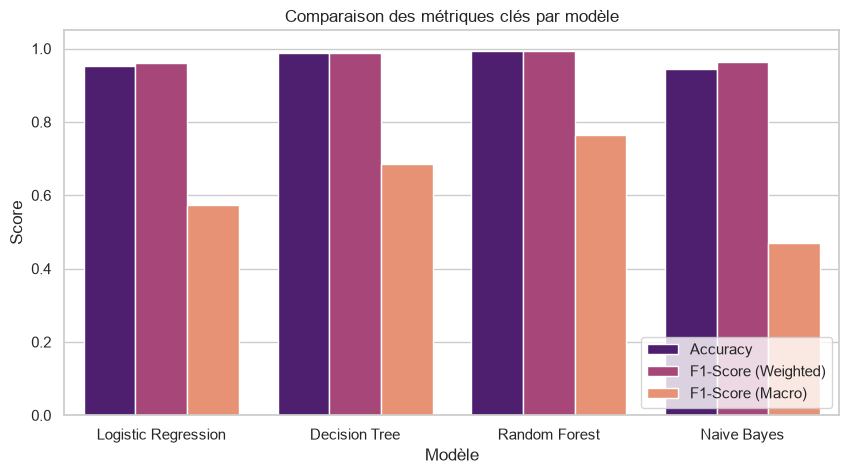

In [42]:
results = []

for name, y_pred in predictions.items():
    results.append({
        "Modèle": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (Weighted)": precision_score(y_test, y_pred, average='weighted'),
        "Recall (Weighted)": recall_score(y_test, y_pred, average='weighted'),
        "F1-Score (Weighted)": f1_score(y_test, y_pred, average='weighted'),
        "F1-Score (Macro)": f1_score(y_test, y_pred, average='macro')
    })

df_results = pd.DataFrame(results)
print("\n=== TABLEAU COMPARATIF DES PERFORMANCES ===")
display(df_results.sort_values(by="F1-Score (Macro)", ascending=False))

# Visualisation des métriques
plt.figure(figsize=(10, 5))
df_results_melted = df_results.melt(id_vars="Modèle", value_vars=["Accuracy", "F1-Score (Weighted)", "F1-Score (Macro)"])
sns.barplot(data=df_results_melted, x="Modèle", y="value", hue="variable", palette="magma")
plt.title("Comparaison des métriques clés par modèle")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.show()

## 6. Matrices de Confusion

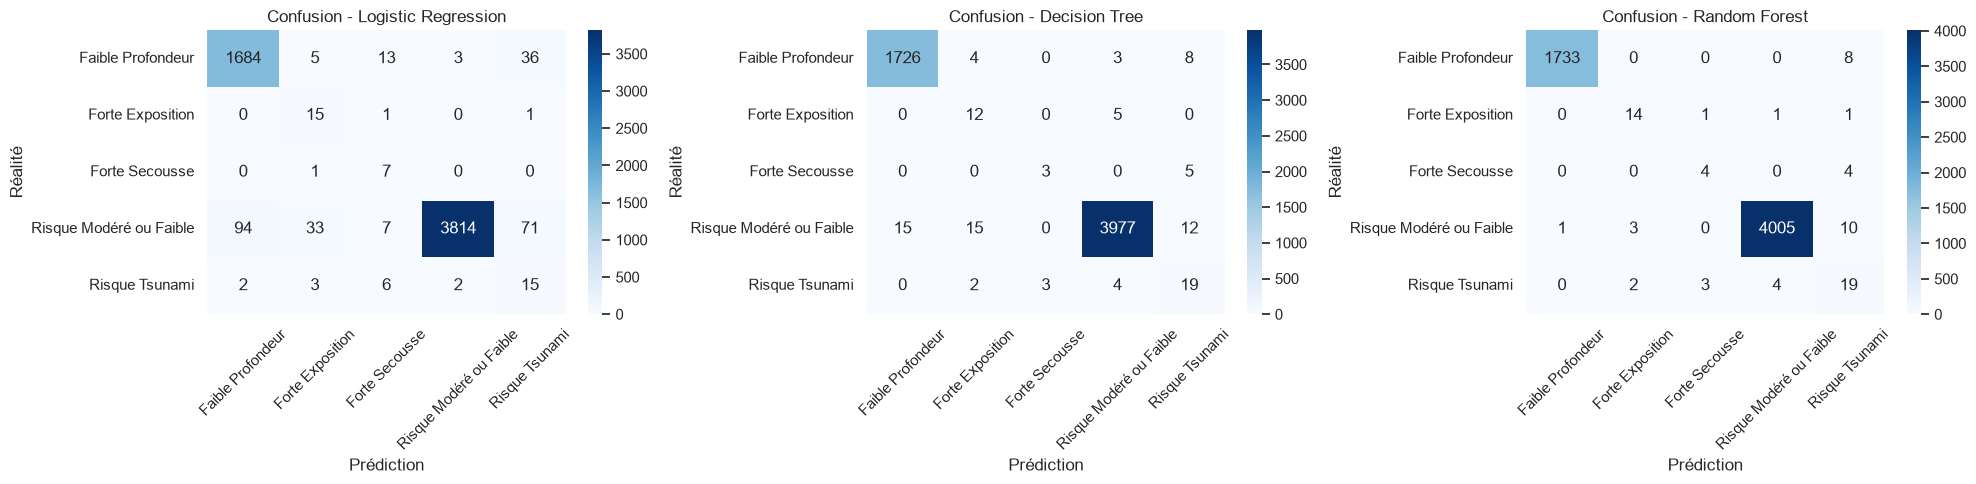

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
labels = np.unique(y)

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=labels, yticklabels=labels)
    ax.set_title(f"Confusion - {name}")
    ax.set_xlabel("Prédiction")
    ax.set_ylabel("Réalité")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 7. Interprétabilité SHAP (Random Forest - Meilleur Modèle)


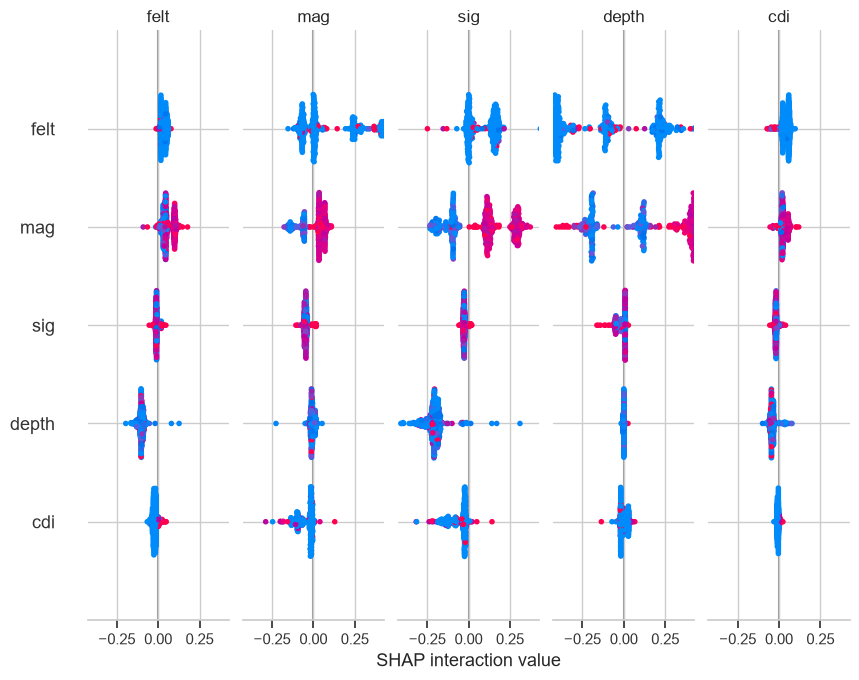

In [44]:
best_model = models["Random Forest"]["model"]

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test.iloc[:500])

shap.summary_plot(shap_values, X_test.iloc[:500], class_names=best_model.classes_)